# Dataset Construction

This notebook builds a tract-level geospatial dataset for modeling urban access to opportunity.

It combines:
- Census tract geometries
- ACS socio-economic variables
- Built environment features from OpenStreetMap
- Amenity density measures

Output:
- A consolidated tract-level GeoDataFrame
- A modeling-ready `.parquet` dataset

## Config

In [1]:
import os
os.environ["CENSUS_API_KEY"] = "cf4fd28398432786abcfab6be3868157c4836d1d"

In [ ]:
NAME = "New York City"
 
STATE = "36" # New York State

COUNTIES = [
    "005",  # Bronx
    "047",  # Brooklyn
    "061",  # Manhattan
    "081",  # Queens
    "085"   # Staten Island
]

# NAME = "Los Angeles"

# STATE = "06"  # California

# COUNTIES = [
#     "037",  # Los Angeles County
#     "059",  # Orange County
#     "111"   # Ventura County
# ]

## Imports

In [3]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import os

from shapely.geometry import Point

import censusdata
import osmnx as ox

pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

## Load Census Tracts

In [4]:
def load_tracts(state_fips):
    print(f"Loading tracts for state {state_fips}...")

    url = (
        f"https://www2.census.gov/geo/tiger/TIGER2023/"
        f"TRACT/tl_2023_{state_fips}_tract.zip"
    )

    gdf = gpd.read_file(url)

    print("Total tracts loaded:", len(gdf))

    gdf = gdf.to_crs(epsg=4326)

    gdf = gdf[gdf.geometry.notnull()].copy()
    gdf["geometry"] = gdf.buffer(0)
    gdf = gdf[gdf.is_valid].copy()

    gdf_proj = gdf.to_crs(epsg=3857)

    gdf["tract_area_km2"] = (
        gdf_proj.geometry.area / 1e6
    )

    return gdf

def filter_counties(gdf, county_list, city_name="city"):
    print(f"\nFiltering tracts for {city_name}...")

    out = gdf[gdf["COUNTYFP"].isin(county_list)].copy()

    print(f"{city_name} tracts:", len(out))

    return out

Loading tracts for state 36...
Total tracts loaded: 5411

Filtering tracts for New York City...
New York City tracts: 2327


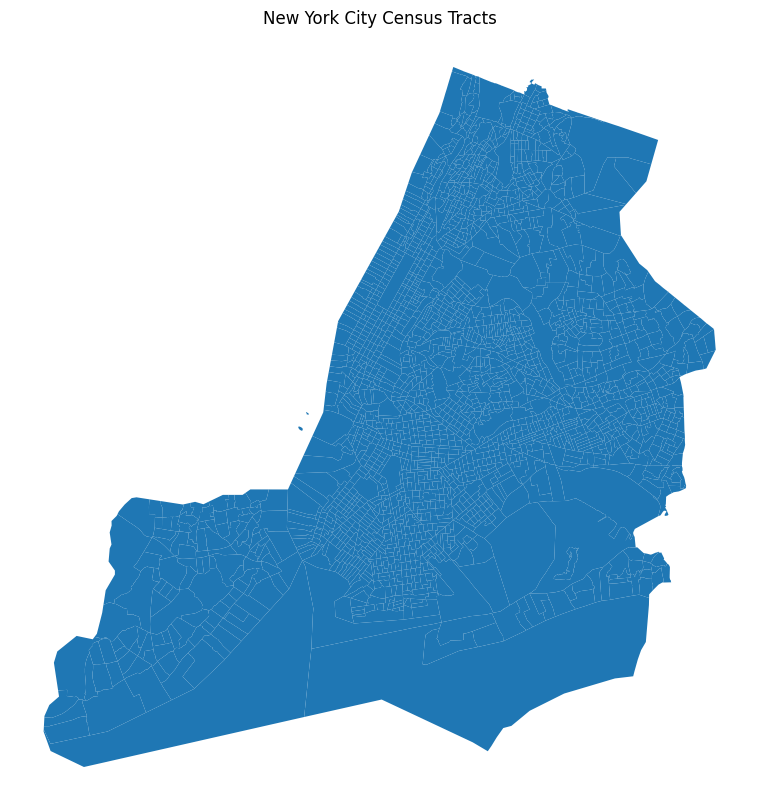

In [5]:
tracts = load_tracts(STATE)
tracts = filter_counties(tracts, COUNTIES, NAME)

tracts.plot(figsize=(10, 10), linewidth=0.2)
plt.title(f"{NAME} Census Tracts")
plt.axis("off")
plt.show()

## Load predictors

In [6]:
ACS_VARIABLES = {

    # Total population
    "total_population": "B01003_001E",

    # Median income
    "median_income": "B19013_001E",

    # AGE - B01001
    # Male under 18
    "m_under_5": "B01001_003E",
    "m_5_9": "B01001_004E",
    "m_10_14": "B01001_005E",
    "m_15_17": "B01001_006E",

    # Female under 18
    "f_under_5": "B01001_027E",
    "f_5_9": "B01001_028E",
    "f_10_14": "B01001_029E",
    "f_15_17": "B01001_030E",

    # Male 65+
    "m_65_66": "B01001_020E",
    "m_67_69": "B01001_021E",
    "m_70_74": "B01001_022E",
    "m_75_79": "B01001_023E",
    "m_80_84": "B01001_024E",
    "m_85_plus": "B01001_025E",

    # Female 65+
    "f_65_66": "B01001_044E",
    "f_67_69": "B01001_045E",
    "f_70_74": "B01001_046E",
    "f_75_79": "B01001_047E",
    "f_80_84": "B01001_048E",
    "f_85_plus": "B01001_049E",

    # Education - B15003
    "bachelors": "B15003_022E",
    "masters": "B15003_023E",
    "professional": "B15003_024E",
    "doctorate": "B15003_025E",
    "pop_25_plus": "B15003_001E",

    # Employment - B23025
    "labor_force": "B23025_003E",
    "employed": "B23025_004E",

    # Poverty - B17001
    "poverty_total": "B17001_001E",
    "below_poverty": "B17001_002E"
}

In [7]:
def load_acs_features(state_fips, county_list, year=2022):
    all_data = []

    vars_to_pull = list(ACS_VARIABLES.values())

    for county in county_list:

        geo = censusdata.censusgeo([
            ("state", state_fips),
            ("county", county),
            ("tract", "*")
        ])

        df = censusdata.download(
            src="acs5",
            year=year,
            geo=geo,
            var=vars_to_pull,
            key=os.getenv("CENSUS_API_KEY")
        )

        df = df.reset_index()

        rename_dict = {
            v: k for k, v in ACS_VARIABLES.items()
        }

        df = df.rename(columns=rename_dict)

        df["tract_id"] = df["index"].apply(
            lambda x: "".join([v for k, v in x.geo])
        )

        all_data.append(df)

    acs = pd.concat(all_data, ignore_index=True)

    return acs

In [8]:
acs = load_acs_features(STATE, COUNTIES)
print(acs.head(2))

                                                                                            index  \
0  Census Tract 1; Bronx County; New York: Summary level: 140, state:36> county:005> tract:000100   
1  Census Tract 2; Bronx County; New York: Summary level: 140, state:36> county:005> tract:000200   

   total_population  median_income  m_under_5  m_5_9  m_10_14  m_15_17  \
0              4446     -666666666          0      0        0       58   
1              4870         115064         62     69      230       71   

   f_under_5  f_5_9  f_10_14  f_15_17  m_65_66  m_67_69  m_70_74  m_75_79  \
0          0      0        0        0        5       19        0        7   
1        162    114      100       14       17       80       31       52   

   m_80_84  m_85_plus  f_65_66  f_67_69  f_70_74  f_75_79  f_80_84  f_85_plus  \
0        0          0        0        0        0        0        0          0   
1       78          0       74      148       68       94       62        108  

In [9]:
def compute_acs_features(df):
    # Replace ACS missing value codes with NaN
    missing_codes = [-666666666, -333333333, -222222222]

    numeric_cols = df.select_dtypes(include="number").columns

    for col in numeric_cols:
        df[col] = df[col].mask(df[col].isin(missing_codes))

    under_18_cols = [
        "m_under_5", "m_5_9", "m_10_14", "m_15_17",
        "f_under_5", "f_5_9", "f_10_14", "f_15_17"
    ]

    df["population_under_18"] = df[under_18_cols].sum(axis=1)

    over_65_cols = [
        "m_65_66", "m_67_69", "m_70_74",
        "m_75_79", "m_80_84", "m_85_plus",
        "f_65_66", "f_67_69", "f_70_74",
        "f_75_79", "f_80_84", "f_85_plus"
    ]

    df["population_over_65"] = df[over_65_cols].sum(axis=1)

    bachelors_cols = [
        "bachelors",
        "masters",
        "professional",
        "doctorate"
    ]

    df["bachelors_or_higher"] = df[bachelors_cols].sum(axis=1)

    # Final features
    df["pct_under_18"] = (
        df["population_under_18"] / df["total_population"]
    )

    df["pct_over_65"] = (
        df["population_over_65"] / df["total_population"]
    )

    df["pct_bachelors_degree"] = (
        df["bachelors_or_higher"] / df["pop_25_plus"]
    )

    df["employment_rate"] = (
        df["employed"] / df["labor_force"]
    )

    df["poverty_rate"] = (
        df["below_poverty"] / df["poverty_total"]
    )

    print("\nDerived features created:")
    print([
        "pct_under_18",
        "pct_over_65",
        "pct_bachelors_degree",
        "employment_rate",
        "poverty_rate"
    ])

    return df

In [10]:
acs = compute_acs_features(acs)
print(acs.head(2))


Derived features created:
['pct_under_18', 'pct_over_65', 'pct_bachelors_degree', 'employment_rate', 'poverty_rate']
                                                                                            index  \
0  Census Tract 1; Bronx County; New York: Summary level: 140, state:36> county:005> tract:000100   
1  Census Tract 2; Bronx County; New York: Summary level: 140, state:36> county:005> tract:000200   

   total_population  median_income  m_under_5  m_5_9  m_10_14  m_15_17  \
0              4446            NaN          0      0        0       58   
1              4870       115064.0         62     69      230       71   

   f_under_5  f_5_9  f_10_14  f_15_17  m_65_66  m_67_69  m_70_74  m_75_79  \
0          0      0        0        0        5       19        0        7   
1        162    114      100       14       17       80       31       52   

   m_80_84  m_85_plus  f_65_66  f_67_69  f_70_74  f_75_79  f_80_84  f_85_plus  \
0        0          0        0        0   

In [11]:
def merge_acs_features(tracts_gdf, acs_df):

    print("\nMerging ACS features with tract geometries...")

    tracts_gdf["tract_id"] = tracts_gdf["GEOID"]

    merged = tracts_gdf.merge(
        acs_df,
        on="tract_id",
        how="left"
    )

    merged["population_density"] = (
        merged["total_population"] / merged["tract_area_km2"]
    )

    print("Merged shape:", merged.shape)

    cols_to_check = [
        "tract_id",
        "total_population",
        "median_income",
        "pct_under_18",
        "pct_over_65",
        "pct_bachelors_degree",
        "employment_rate",
        "poverty_rate",
        "population_density"
    ]

    print("\nSample merged rows:")
    print(merged[cols_to_check].head())

    return merged

In [12]:
tracts = merge_acs_features(tracts, acs)
print(tracts.columns.tolist())


Merging ACS features with tract geometries...
Merged shape: (2327, 57)

Sample merged rows:
      tract_id  total_population  median_income  pct_under_18  pct_over_65  \
0  36081003400              2559        79728.0      0.178585     0.117233   
1  36081003900              1436        53468.0      0.157382     0.072423   
2  36081003600              4004        86582.0      0.255245     0.155345   
3  36081003700                 0            NaN           NaN          NaN   
4  36081003800              2514        85859.0      0.280827     0.095465   

   pct_bachelors_degree  employment_rate  poverty_rate  population_density  
0              0.262774         0.869735      0.160126         6869.633349  
1              0.327256         0.989781      0.227019         5599.661929  
2              0.235552         0.909272      0.082371        12778.128973  
3                   NaN              NaN           NaN            0.000000  
4              0.314629         0.949377      0.11664

In [13]:
def add_built_environment_features(tracts_gdf):

    print("\nComputing built environment features...")

    tracts_gdf = tracts_gdf.copy()

    tracts_gdf["tract_idx"] = tracts_gdf.index

    tracts_latlon = tracts_gdf.to_crs(epsg=4326)

    city_geom = tracts_latlon.union_all()

    print("Downloading road network...")

    G = ox.graph_from_polygon(
        city_geom,
        network_type="drive",
        simplify=True
    )

    nodes, edges = ox.graph_to_gdfs(G)

    edges = edges.to_crs(epsg=3857)
    nodes = nodes.to_crs(epsg=3857)


    intersections = nodes[
        nodes["street_count"] >= 3
    ].copy()

    print("Downloading transit stops...")

    transit = ox.features_from_polygon(
        city_geom,
        tags={
            "highway": "bus_stop",
            "railway": "station"
        }
    )

    if len(transit) > 0:
        transit = transit.to_crs(epsg=3857)

    tracts_proj = tracts_gdf.to_crs(epsg=3857)

    edges["road_length_km"] = (
        edges.geometry.length / 1000
    )

    roads_joined = gpd.sjoin(
        edges,
        tracts_proj,
        how="inner",
        predicate="intersects"
    )

    road_lengths = roads_joined.groupby(
        "tract_idx"
    )["road_length_km"].sum()

    inter_joined = gpd.sjoin(
        intersections,
        tracts_proj,
        how="inner",
        predicate="within"
    )

    inter_counts = inter_joined.groupby(
        "tract_idx"
    ).size()

    if len(transit) > 0:

        transit_joined = gpd.sjoin(
            transit,
            tracts_proj,
            how="inner",
            predicate="within"
        )

        transit_counts = transit_joined.groupby(
            "tract_idx"
        ).size()

    else:
        transit_counts = pd.Series(dtype=float)

    tracts_gdf["road_length_km"] = (
        tracts_gdf["tract_idx"]
        .map(road_lengths)
        .fillna(0)
    )

    tracts_gdf["intersection_count"] = (
        tracts_gdf["tract_idx"]
        .map(inter_counts)
        .fillna(0)
    )

    tracts_gdf["transit_stop_count"] = (
        tracts_gdf["tract_idx"]
        .map(transit_counts)
        .fillna(0)
    )

    tracts_gdf["road_density"] = (
        tracts_gdf["road_length_km"]
        / tracts_gdf["tract_area_km2"]
    )

    tracts_gdf["intersection_density"] = (
        tracts_gdf["intersection_count"]
        / tracts_gdf["tract_area_km2"]
    )

    tracts_gdf["transit_stop_density"] = (
        tracts_gdf["transit_stop_count"]
        / tracts_gdf["tract_area_km2"]
    )

    print("Built environment features added.")

    return tracts_gdf

In [14]:
tracts = add_built_environment_features(tracts)
print(tracts.columns.tolist())


Computing built environment features...
Built environment features added.
['STATEFP', 'COUNTYFP', 'TRACTCE', 'GEOID', 'GEOIDFQ', 'NAME', 'NAMELSAD', 'MTFCC', 'FUNCSTAT', 'ALAND', 'AWATER', 'INTPTLAT', 'INTPTLON', 'geometry', 'tract_area_km2', 'tract_id', 'index', 'total_population', 'median_income', 'm_under_5', 'm_5_9', 'm_10_14', 'm_15_17', 'f_under_5', 'f_5_9', 'f_10_14', 'f_15_17', 'm_65_66', 'm_67_69', 'm_70_74', 'm_75_79', 'm_80_84', 'm_85_plus', 'f_65_66', 'f_67_69', 'f_70_74', 'f_75_79', 'f_80_84', 'f_85_plus', 'bachelors', 'masters', 'professional', 'doctorate', 'pop_25_plus', 'labor_force', 'employed', 'poverty_total', 'below_poverty', 'population_under_18', 'population_over_65', 'bachelors_or_higher', 'pct_under_18', 'pct_over_65', 'pct_bachelors_degree', 'employment_rate', 'poverty_rate', 'population_density', 'tract_idx', 'road_length_km', 'intersection_count', 'transit_stop_count', 'road_density', 'intersection_density', 'transit_stop_density']


## Plot Predictors

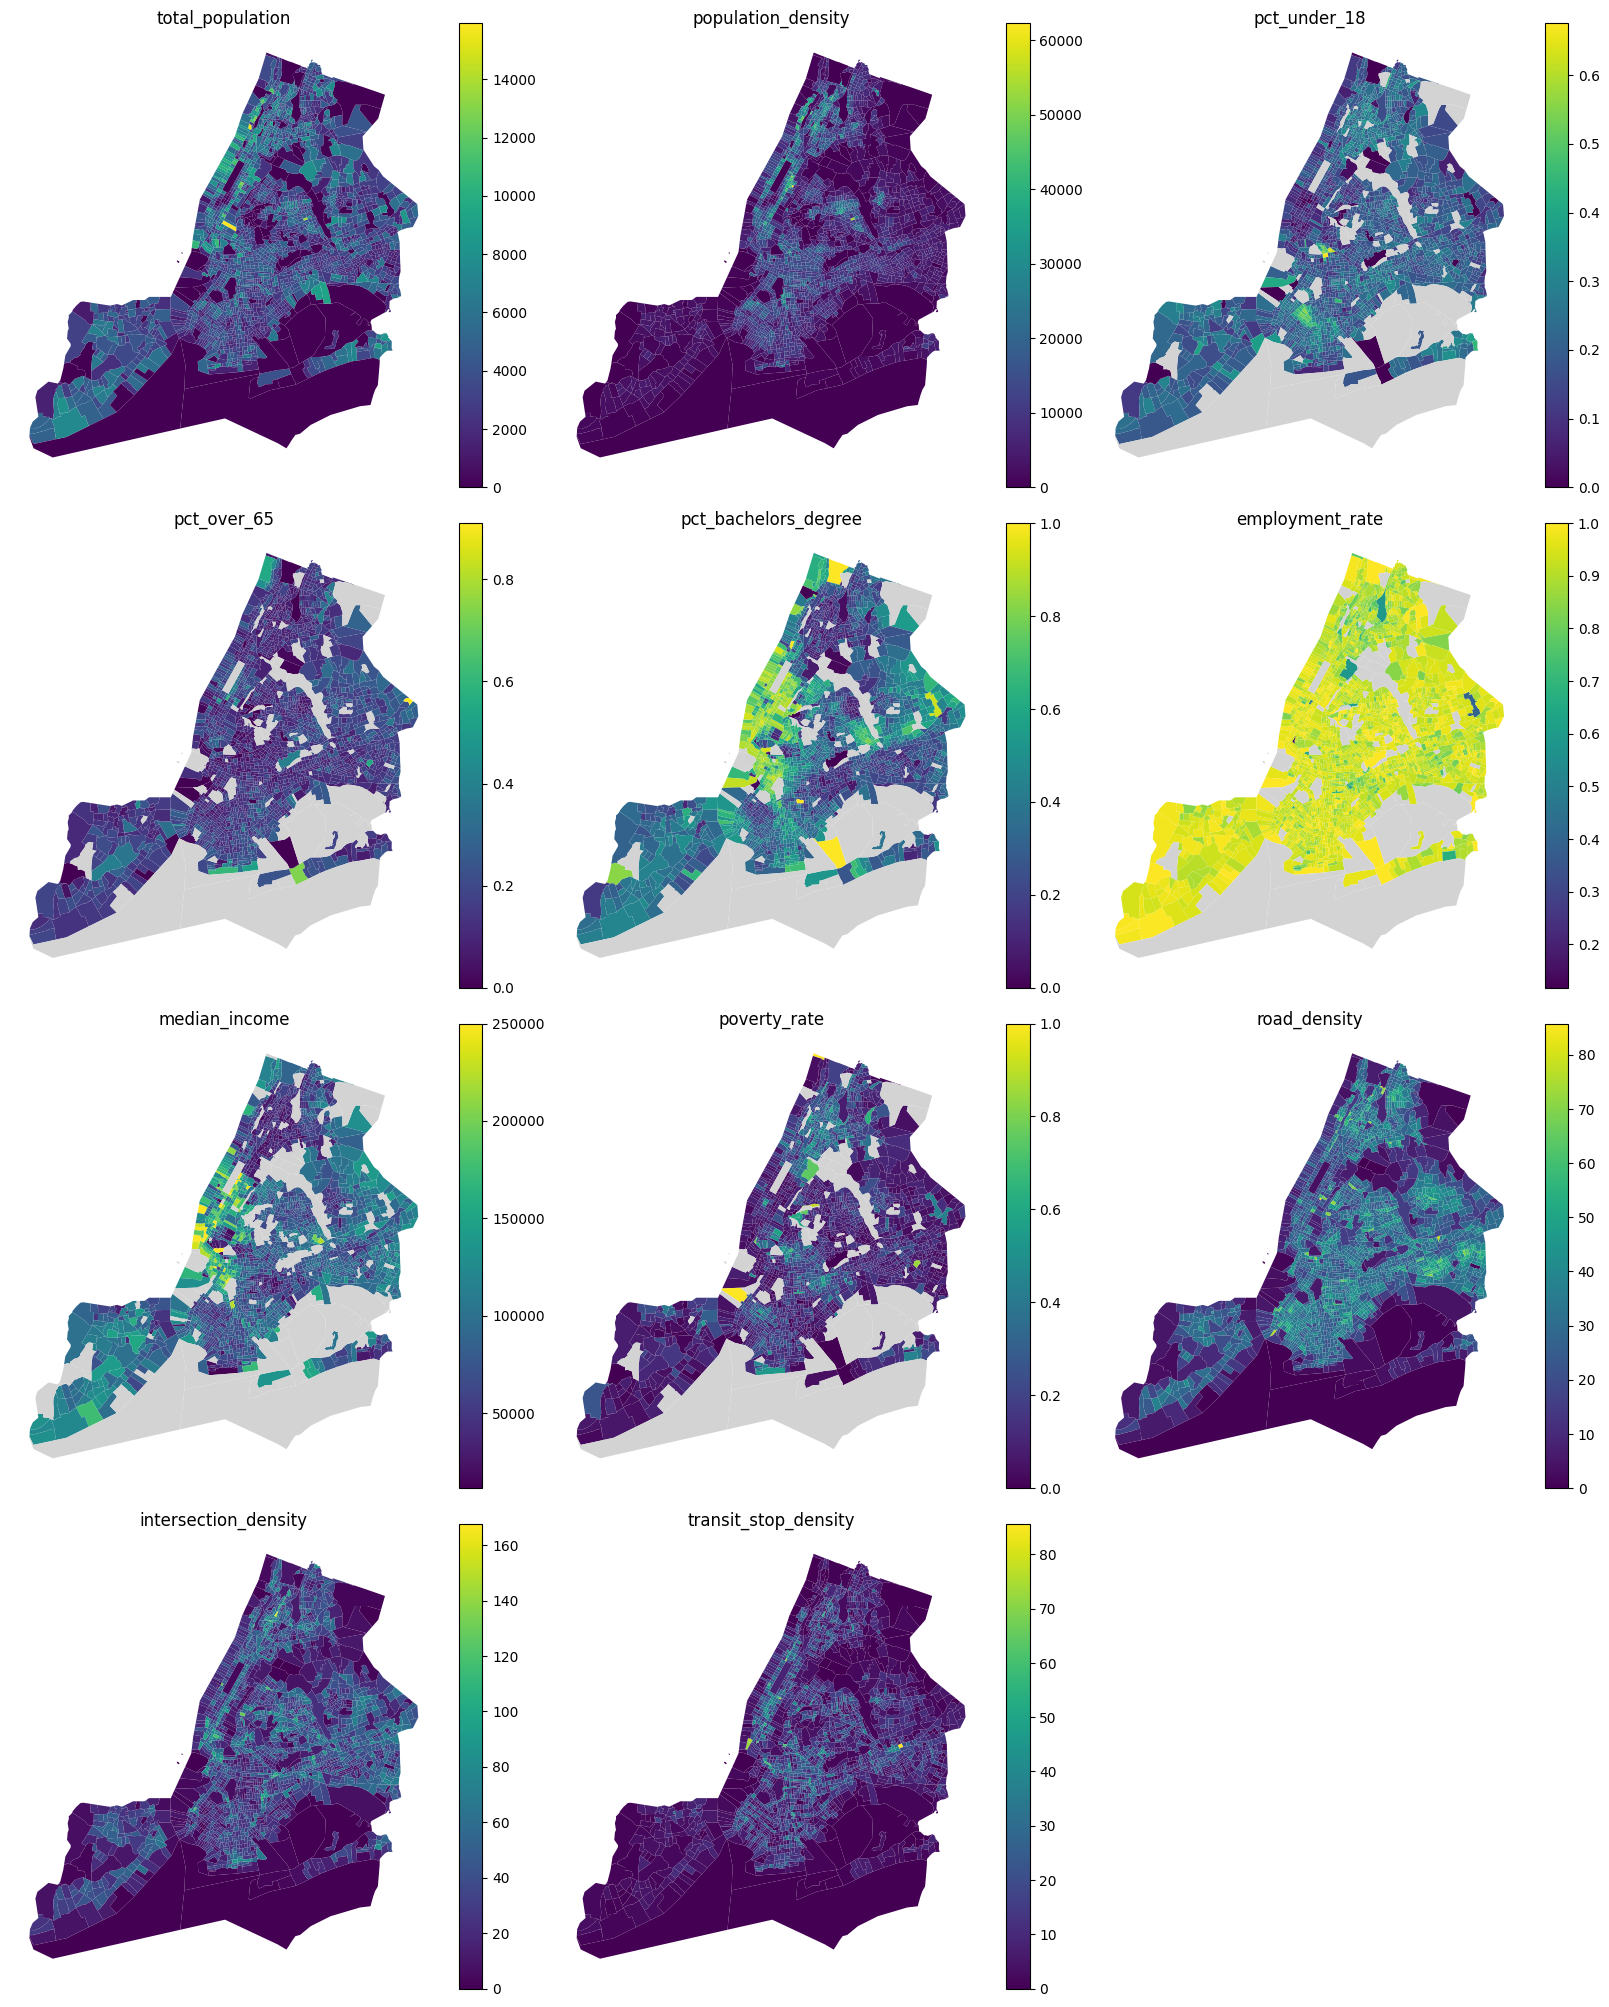

In [15]:
features = [
    "total_population",
    "population_density",
    "pct_under_18",
    "pct_over_65",
    "pct_bachelors_degree",
    "employment_rate",
    "median_income",
    "poverty_rate",
    "road_density",
    "intersection_density",
    "transit_stop_density"
]

n_cols = 3
n_rows = (len(features) + n_cols - 1) // n_cols

# compute aspect-aware figure size
fig_width = 16
fig_height = 5 * n_rows

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(fig_width, fig_height),
    constrained_layout=True
)

axes = axes.flatten()

for i, var in enumerate(features):

    tracts.plot(
        column=var,
        cmap="viridis",
        legend=True,
        ax=axes[i],
        missing_kwds={"color": "lightgrey"}
    )

    axes[i].set_title(var)
    axes[i].axis("off")

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.show()

## Load target variable

In [16]:
def add_amenity_density_targets(tracts_gdf):

    print("\nComputing amenity density target variables...")

    tracts_gdf = tracts_gdf.copy()

    city_geom = (
        tracts_gdf
        .to_crs(epsg=4326)
        .union_all()
    )

    amenity_configs = {

        "grocery": {
            "tags": {
                "shop": [
                    "supermarket",
                    "grocery",
                    "convenience"
                ]
            }
        },

        "schools": {
            "tags": {
                "amenity": [
                    "school",
                    "college",
                    "university",
                    "kindergarten"
                ]
            }
        },

        "healthcare": {
            "tags": {
                "amenity": [
                    "hospital",
                    "clinic",
                    "doctors",
                    "pharmacy"
                ]
            }
        },

        "parks": {
            "tags": {
                "leisure": [
                    "park",
                    "playground",
                    "garden"
                ]
            }
        }
    }


    tracts_proj = tracts_gdf.to_crs(epsg=3857).copy()

    tracts_proj["tract_idx"] = tracts_proj.index

    for name, config in amenity_configs.items():

        print(f"\nDownloading {name} data from OSM...")

        amenities = ox.features_from_polygon(
            city_geom,
            tags=config["tags"]
        )

        amenities = amenities[
            amenities.geometry.notnull()
        ].copy()

        amenities = amenities[
            amenities.is_valid
        ].copy()

        print(f"Raw {name} features:", len(amenities))

        if len(amenities) == 0:

            tracts_gdf[f"{name}_count"] = 0
            tracts_gdf[f"{name}_density"] = 0

            continue

        amenities = amenities.to_crs(epsg=3857)

        amenities["geometry"] = (
            amenities.geometry.centroid
        )

        amenities = amenities[
            ~amenities.geometry.is_empty
        ].copy()

        joined = gpd.sjoin(
            amenities,
            tracts_proj[["tract_idx", "geometry"]],
            how="inner",
            predicate="within"
        )

        counts = joined.groupby("tract_idx").size()

        tracts_gdf[f"{name}_count"] = (
            tracts_gdf.index
            .map(counts)
            .fillna(0)
        )

        tracts_gdf[f"{name}_density"] = (
            tracts_gdf[f"{name}_count"]
            / tracts_gdf["tract_area_km2"]
        )

        print(f"{name.capitalize()} density added.")

    return tracts_gdf

In [17]:
tracts = add_amenity_density_targets(tracts)


Computing amenity density target variables...

Raw grocery features: 3876
Grocery density added.

Raw schools features: 2208
Schools density added.

Raw healthcare features: 2550
Healthcare density added.

Raw parks features: 12517
Parks density added.


## Load Employment Data

In [18]:
def load_lodes_jobs(state_abbrev="ny", year=2021):

    print("\nLoading LODES employment data...")

    url = (
        f"https://lehd.ces.census.gov/data/lodes/LODES8/"
        f"{state_abbrev}/wac/"
        f"{state_abbrev}_wac_S000_JT00_{year}.csv.gz"
    )

    jobs = pd.read_csv(
        url,
        compression="gzip"
    )

    print("Rows loaded:", len(jobs))

    return jobs

In [19]:
jobs = load_lodes_jobs()


Loading LODES employment data...
Rows loaded: 104520


In [20]:
# %%
def add_jobs_density(tracts_gdf, jobs_df):

    print("\nComputing jobs density...")

    jobs_df = jobs_df.copy()

    # workplace block -> tract
    jobs_df["tract_id"] = (
        jobs_df["w_geocode"]
        .astype(str)
        .str[:11]
    )

    tract_jobs = (
        jobs_df.groupby("tract_id")["C000"]
        .sum()
        .reset_index()
    )

    tract_jobs = tract_jobs.rename(
        columns={"C000": "total_jobs"}
    )

    tracts_gdf = tracts_gdf.copy()

    tracts_gdf["tract_id"] = (
        tracts_gdf["GEOID"]
    )

    tracts_gdf = tracts_gdf.merge(
        tract_jobs,
        on="tract_id",
        how="left"
    )

    tracts_gdf["total_jobs"] = (
        tracts_gdf["total_jobs"]
        .fillna(0)
    )

    tracts_gdf["jobs_density"] = (
        tracts_gdf["total_jobs"]
        / tracts_gdf["tract_area_km2"]
    )

    print("Jobs density added.")

    return tracts_gdf

In [21]:
tracts = add_jobs_density(
    tracts,
    jobs
)


Computing jobs density...
Jobs density added.


## Compute Composite Urban Opportunity Index

In [22]:
def compute_urban_opportunity_index(gdf):

    print("\nComputing urban opportunity index...")

    gdf = gdf.copy()

    opportunity_vars = [
        "grocery_density",
        "schools_density",
        "healthcare_density",
        "parks_density",
        "jobs_density"
    ]

    # ---------------------------------
    # Log-transform to reduce skew
    # ---------------------------------
    for col in opportunity_vars:

        gdf[f"{col}_log"] = np.log1p(
            gdf[col]
        )

    # ---------------------------------
    # Standardize (z-score)
    # ---------------------------------
    for col in opportunity_vars:

        log_col = f"{col}_log"

        mean = gdf[log_col].mean()
        std = gdf[log_col].std()

        if std == 0:
            gdf[f"{col}_z"] = 0
        else:
            gdf[f"{col}_z"] = (
                (gdf[log_col] - mean) / std
            )

    # ---------------------------------
    # Composite score
    # ---------------------------------
    gdf["urban_opportunity_index_raw"] = (
        gdf[[f"{c}_z" for c in opportunity_vars]]
        .mean(axis=1)
    )

    # ---------------------------------
    # Normalize to 0-100
    # ---------------------------------
    min_val = gdf["urban_opportunity_index_raw"].min()
    max_val = gdf["urban_opportunity_index_raw"].max()

    gdf["urban_opportunity_index"] = (
        100
        * (
            gdf["urban_opportunity_index_raw"] - min_val
        )
        / (max_val - min_val)
    )

    print("Urban opportunity index added.")

    return gdf

In [23]:
tracts = compute_urban_opportunity_index(tracts)
print(tracts.columns.tolist())


Computing urban opportunity index...
Urban opportunity index added.
['STATEFP', 'COUNTYFP', 'TRACTCE', 'GEOID', 'GEOIDFQ', 'NAME', 'NAMELSAD', 'MTFCC', 'FUNCSTAT', 'ALAND', 'AWATER', 'INTPTLAT', 'INTPTLON', 'geometry', 'tract_area_km2', 'tract_id', 'index', 'total_population', 'median_income', 'm_under_5', 'm_5_9', 'm_10_14', 'm_15_17', 'f_under_5', 'f_5_9', 'f_10_14', 'f_15_17', 'm_65_66', 'm_67_69', 'm_70_74', 'm_75_79', 'm_80_84', 'm_85_plus', 'f_65_66', 'f_67_69', 'f_70_74', 'f_75_79', 'f_80_84', 'f_85_plus', 'bachelors', 'masters', 'professional', 'doctorate', 'pop_25_plus', 'labor_force', 'employed', 'poverty_total', 'below_poverty', 'population_under_18', 'population_over_65', 'bachelors_or_higher', 'pct_under_18', 'pct_over_65', 'pct_bachelors_degree', 'employment_rate', 'poverty_rate', 'population_density', 'tract_idx', 'road_length_km', 'intersection_count', 'transit_stop_count', 'road_density', 'intersection_density', 'transit_stop_density', 'grocery_count', 'grocery_densit

## Visualize Target Variables

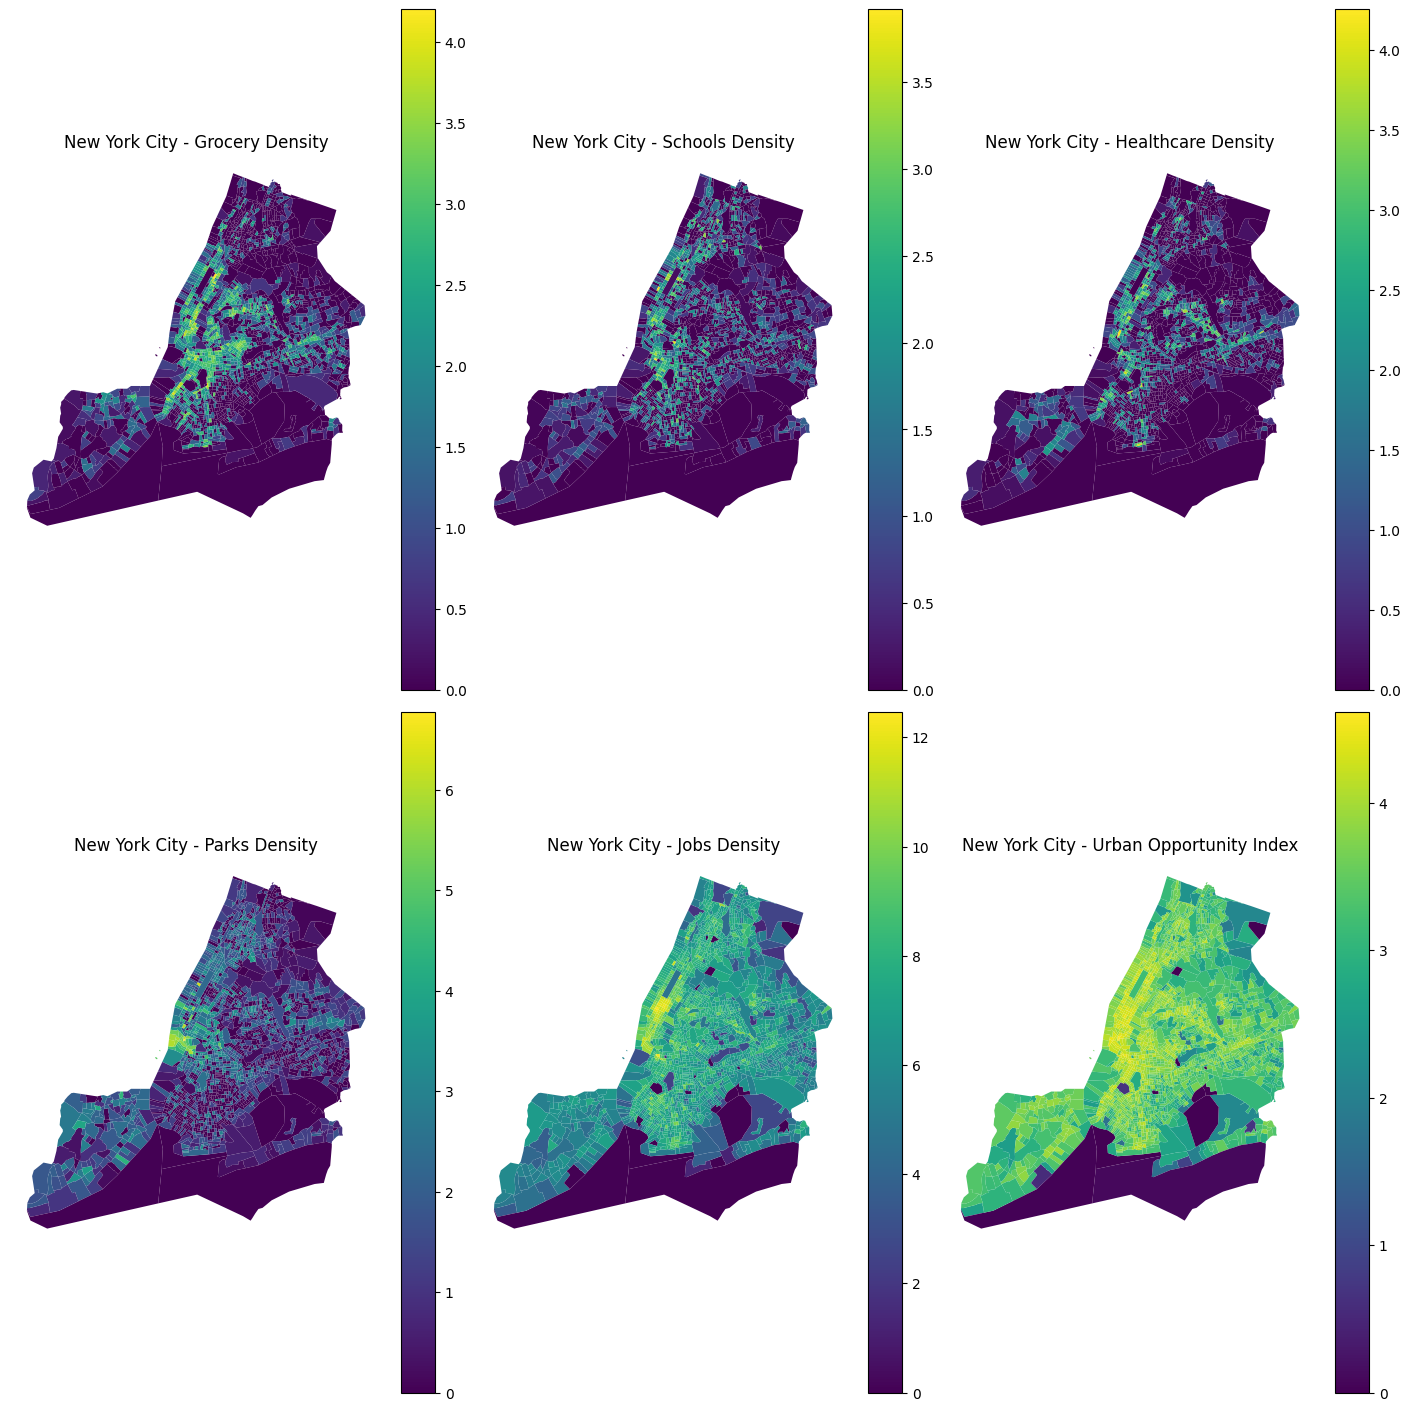

In [24]:
# %%
target_plots = [
    "grocery_density",
    "schools_density",
    "healthcare_density",
    "parks_density",
    "jobs_density",
    "urban_opportunity_index"
]

n_cols = 3
n_rows = 2

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(14, 14),
    constrained_layout=True
)

axes = axes.flatten()

for i, var in enumerate(target_plots):

    plot_df = tracts.copy()

    # log transform to reduce skew
    plot_df[f"log_{var}"] = np.log1p(
        plot_df[var]
    )

    plot_df.plot(
        column=f"log_{var}",
        cmap="viridis",
        legend=True,
        ax=axes[i],
        missing_kwds={"color": "lightgrey"}
    )

    axes[i].set_title(
        f"{NAME} - {var.replace('_', ' ').title()}"
    )

    axes[i].axis("off")

for j in range(i + 1, len(axes)):
    axes[j].axis("off")
    
plt.show()

## Build Final Modeling Dataset

In [25]:
def save_ml_dataset(tracts, path):

    df = tracts.copy()

    # ML RELEVANT COLUMNS
    keep_cols = [

        "GEOID",

        "total_population",
        "median_income",
        "population_density",
        "pct_under_18",
        "pct_over_65",
        "pct_bachelors_degree",
        "employment_rate",
        "poverty_rate",

        "road_density",
        "intersection_density",
        "transit_stop_density",

        "urban_opportunity_index"
    ]

    df = df[keep_cols].copy()

    df.to_parquet(path, index=False)

    print(f"Saved ML dataset: {path}")
    print(df.shape)

    return df

In [26]:
NAME_FILE = NAME.strip().lower().replace(" ", "_")

final_df = save_ml_dataset(
    tracts,
    f"../data/{NAME_FILE}_tract_dataset.parquet"
)

print(final_df.head())

Saved ML dataset: ../data/new_york_city_tract_dataset.parquet
(2327, 13)
         GEOID  total_population  median_income  population_density  \
0  36081003400              2559        79728.0         6869.633349   
1  36081003900              1436        53468.0         5599.661929   
2  36081003600              4004        86582.0        12778.128973   
3  36081003700                 0            NaN            0.000000   
4  36081003800              2514        85859.0         8195.434026   

   pct_under_18  pct_over_65  pct_bachelors_degree  employment_rate  \
0      0.178585     0.117233              0.262774         0.869735   
1      0.157382     0.072423              0.327256         0.989781   
2      0.255245     0.155345              0.235552         0.909272   
3           NaN          NaN                   NaN              NaN   
4      0.280827     0.095465              0.314629         0.949377   

   poverty_rate  road_density  intersection_density  transit_stop_density